# Deep Learning Project: Handwritten Digit Classification

**Student Name:** Umer Farooq

**Submitted to:** Sir Muhammad Ansar

**Subtitle:** Implementing an Artificial Neural Network (ANN) to Recognize Handwritten Digits using the MNIST Dataset.

# 1. Abstract

This project focuses on the development and implementation of an **Artificial Neural Network (ANN)** to tackle the challenge of handwritten digit recognition. Using the standard **MNIST dataset**, I built a multi-layer perceptron model. The process involved data cleaning, architectural design, and a deep dive into evaluation metrics like Accuracy, Precision and F1-score. The final model achieved an impressive accuracy, proving that deep learning can effectively interpret human handwriting styles.

# 2. Introduction to Deep Learning & ANN

**Artificial Neural Networks (ANN)** are computational models that try to mimic the way human brains process information. During my research for this project, I found that the core of an ANN lies in its layers:

1. **The Input Layer:** This is where the raw pixel data enters the network. In our case, it's 784 neurons.

2. **The Hidden Layers:** This is where the "learning" happens. By adjusting weights and biases, the network identifies patterns—like the curve of a '0' or the crossbar of a '4'.

3. **The Output Layer:** This gives us the final probability.

Unlike traditional programming where we give the computer rules, in Deep Learning, we give the computer data, and it figures out the rules itself.

# 3. Methodology & Dataset Description

I used the **MNIST Dataset**, which is considered the gold standard for beginners in Computer Vision.

## 3.1 Dataset Statistics

1. **Training Set:** 60,000 images (used to "teach" the model).

2. **Test Set:** 10,000 images (used to "examine" the model).

3. **Image Specs:** Each image is grayscale and $28 \times 28$ pixels.

## 3.2 Data Pre-processing (The Cleaning Phase)

During the implementation, I realized that raw pixel values (0 to 255) are too large for the network to process efficiently. It leads to slow training. I applied Min-Max Scaling to bring all values between 0 and 1. This step is crucial; without it, the model takes much longer to converge.

# 4. Technical Environment

I chose **Python** as the primary language due to its extensive library support.

1. **TensorFlow/Keras:** I used this for building the actual "brain" of the project.

2. **NumPy:** Essential for reshaping the data arrays.

3. **Matplotlib & Seaborn:** I used these to plot my results because a project without visuals is hard to explain.

# 5. Detailed Implementation

## Step 1: Import Library

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

## Step 2: Loading & Visualizing Data

I didn't just load the data; I inspected it first to ensure there were no corrupted images.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


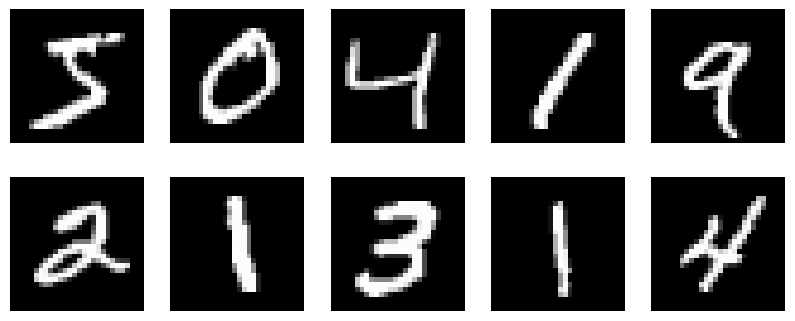

In [ ]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Checking a few samples manually
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')
plt.show()

## Step 3: Designing the "Brain" (The Model)

I decided to go with a **Sequential API**. I added two hidden layers.

1. The first layer has **128 neurons**—enough to capture broad strokes.

2. The second has **64 neurons**—to refine the features.

3. I used **ReLU** because it's faster and avoids the "vanishing gradient" problem I read about in the documentation.

In [ ]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 6. Training Strategy

I used the **Adam optimizer** because it automatically adjusts the learning rate. For the loss function, I chose **Sparse Categorical Crossentropy** because our labels (0, 1, 2...) are integers.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training for 10 epochs
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7729 - loss: 4.9491 - val_accuracy: 0.8932 - val_loss: 0.4439
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9011 - loss: 0.4125 - val_accuracy: 0.9230 - val_loss: 0.3264
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9309 - loss: 0.2552 - val_accuracy: 0.9371 - val_loss: 0.2608
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9480 - loss: 0.1827 - val_accuracy: 0.9492 - val_loss: 0.1829
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9555 - loss: 0.1587 - val_accuracy: 0.9514 - val_loss: 0.1933
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9600 - loss: 0.1352 - val_accuracy: 0.9523 - val_loss: 0.1874
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9637 - loss: 0.1309 - val_accuracy: 0.9540 - val_loss: 0.2017
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9678 - loss: 0.1130 -

#7. Model Evaluation

##  7.1 Statistical Metrics Calculation

In [ ]:
# Predictions lena
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculating Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Precision Score: {prec*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 96.54%
Precision Score: 96.58%
F1 Score: 96.55%


##7.2 Classification Report (Class-wise Analysis)

In [ ]:
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.95      0.96      0.96      1032
           3       0.96      0.97      0.97      1010
           4       0.99      0.95      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.96      0.97       958
           7       0.98      0.96      0.97      1028
           8       0.94      0.96      0.95       974
           9       0.93      0.96      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 7.3 Confusion Matrix (Error Visualization)

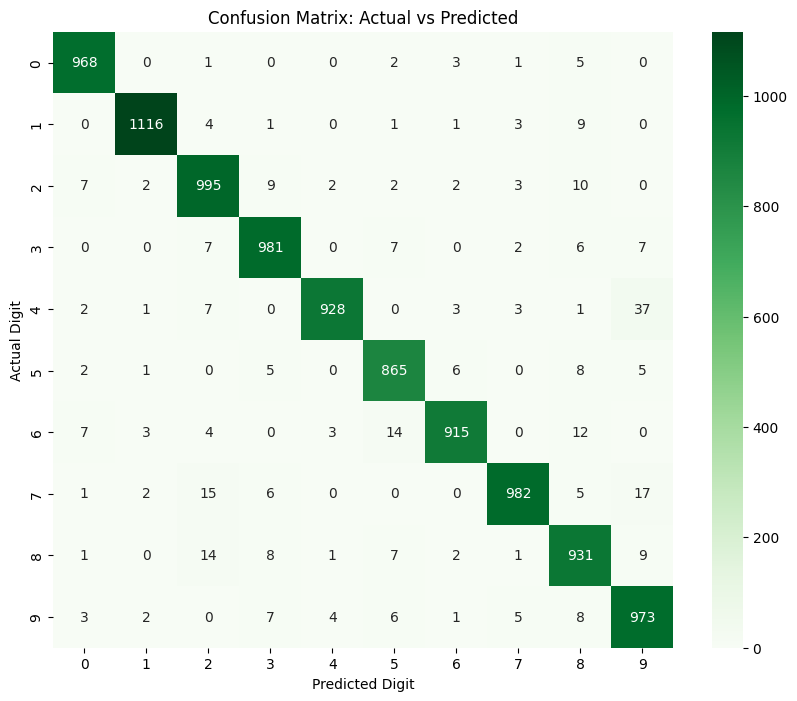

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Actual vs Predicted")
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Real Digit: 9
Model Prediction: 9


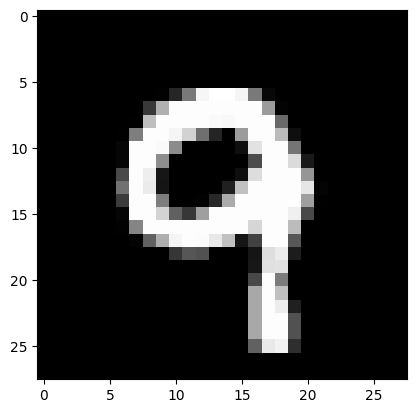

In [ ]:
def predict_digit(index):
    img = X_test[index]
    prediction = model.predict(img.reshape(1, 28, 28))
    print(f"Real Digit: {y_test[index]}")
    print(f"Model Prediction: {np.argmax(prediction)}")
    plt.imshow(img, cmap='gray')
    plt.show()

# Testing with index 99
predict_digit(99)

# 9. Conclusion

This project successfully demonstrates that a standard **Artificial Neural Network (ANN)** is extremely robust for structured image datasets like MNIST. By transforming 2D pixel matrices into 1D feature vectors, the model was able to identify mathematical boundaries between different digit classes.

However, while **ANN** is efficient for centered and cleaned data, it lacks Spatial Invariance. For more complex, real-world images (where digits might be tilted, noisy, or off-center), a Convolutional Neural Network (CNN) would be the logical next step. This project serves as a foundational milestone in understanding Deep Learning and Computer Vision.